# 3. Visão Computacional (Artificial)

**Ideia:** obter informações a partir de uma imagem.

**Aplicação escolhida:** contar objetos separados sobre um fundo branco. É uma demonstração básica de contagem de peças.

**Entrada:** imagem dos círculos. **Saída principal:** quantidade de objetos encontrados.

Adaptação do [exemplo de contornos do repositório OpenCV](https://github.com/opencv/opencv/blob/4.x/doc/py_tutorials/py_imgproc/py_contours/py_contours_begin/py_contours_begin.markdown). Ajustamos a separação do fundo e contamos os contornos externos.



**Passo 1: separar os objetos do fundo.**

Convertemos a imagem para cinza. Depois, usamos o limite `200`: pixels com intensidade até esse valor ficam brancos, e os mais claros ficam pretos. Assim, os objetos ficam brancos e o fundo fica preto.

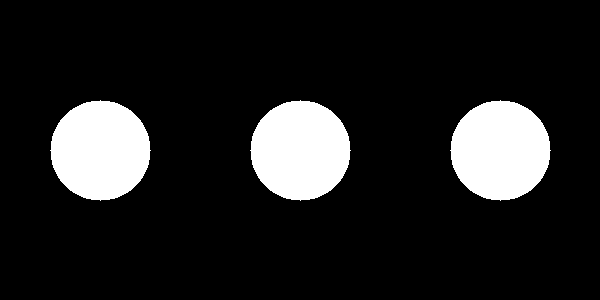

In [ ]:
import cv2
from IPython.display import Image, display

imagem = cv2.imread("resultados/1_sintese.png")
assert imagem is not None, "Execute o notebook 01 para criar a imagem de entrada."
cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

_, mascara = cv2.threshold(cinza, 200, 255, cv2.THRESH_BINARY_INV)
cv2.imwrite("resultados/3_mascara.png", mascara)
display(Image(filename="resultados/3_mascara.png"))

**Passo 2: encontrar e contar os contornos.**

Um contorno é a borda de uma região. `RETR_EXTERNAL` seleciona as bordas externas; `CHAIN_APPROX_SIMPLE` guarda os pontos necessários para representá-las. `len` conta quantos contornos foram encontrados.

In [ ]:
contornos, _ = cv2.findContours(
    mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
quantidade = len(contornos)
print(f"Objetos encontrados: {quantidade}")

Objetos encontrados: 3


**Passo 3: marcar o que foi encontrado.** As bordas pretas abaixo ajudam a conferir a contagem.

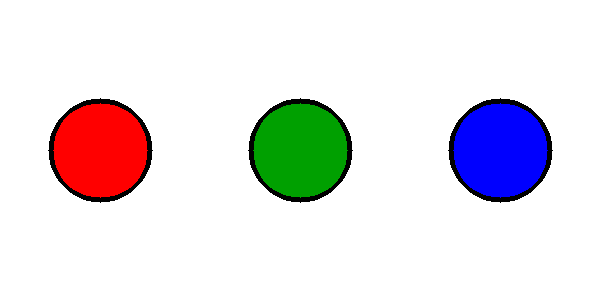

In [ ]:
marcada = imagem.copy()
cv2.drawContours(marcada, contornos, -1, (0, 0, 0), 3)
cv2.imwrite("resultados/3_visao.png", marcada)
display(Image(filename="resultados/3_visao.png"))

Com a imagem original, o resultado é **3 objetos**. A quantidade foi calculada pelos contornos da imagem.

A conversão e a separação do fundo são etapas de **processamento de imagens**. Usá-las para extrair uma contagem é o objetivo de **visão computacional** deste exemplo.

**Limitação:** este método conta regiões separadas; não identifica o que elas são. Objetos encostados, cores muito claras ou um fundo com detalhes podem atrapalhar. Não há treinamento de inteligência artificial neste exemplo.
